In [12]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

In [16]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [2]:
total_titles = len(df)

movies = len(df[df["type"]=="Movie"])

tv = len(df[df["type"]=="TV Show"])

print(f"Total Titles : {total_titles}")
print(f"Movies : {movies}")
print(f"TV Shows : {tv}")

Total Titles : 8807
Movies : 6131
TV Shows : 2676


In [3]:
country = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

print(country.value_counts().head(10))

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [4]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

print(genres.value_counts().head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [5]:
directors = (
    df[df["director"]!="Unknown"]["director"]
    .str.split(", ")
    .explode()
)

print(directors.value_counts().head(10))

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


In [6]:
print(df["rating"].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


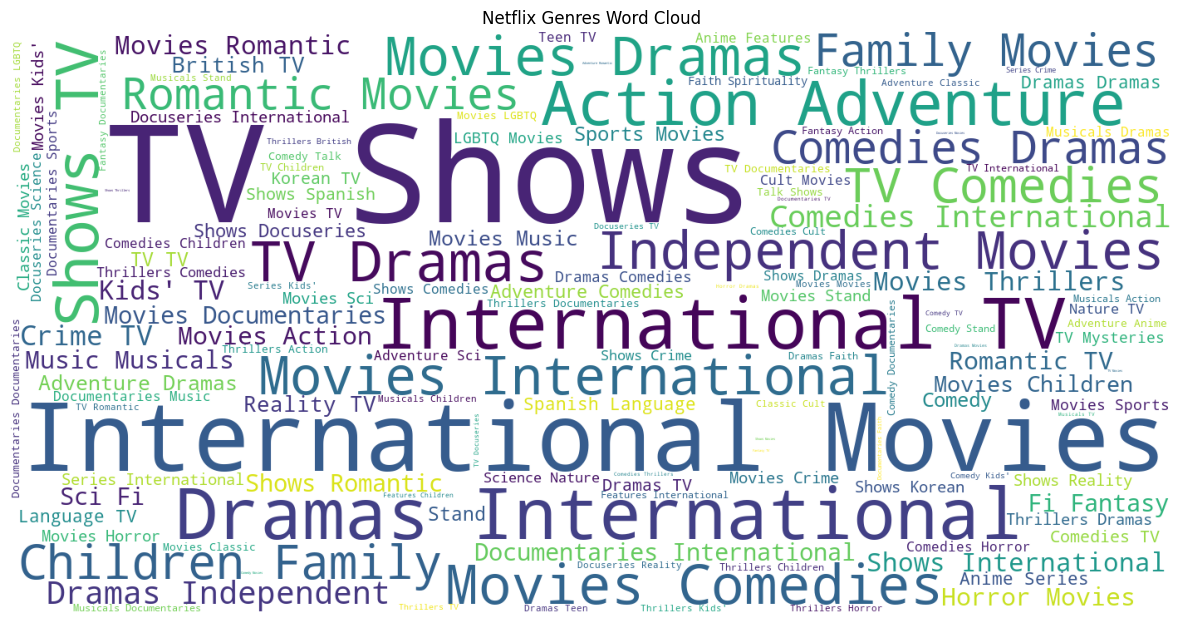

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["listed_in"].dropna())

wc = WordCloud(
    width=1400,
    height=700,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wc)

plt.axis("off")

plt.title("Netflix Genres Word Cloud")

plt.savefig("../images/11_genre_wordcloud.png")

plt.show()

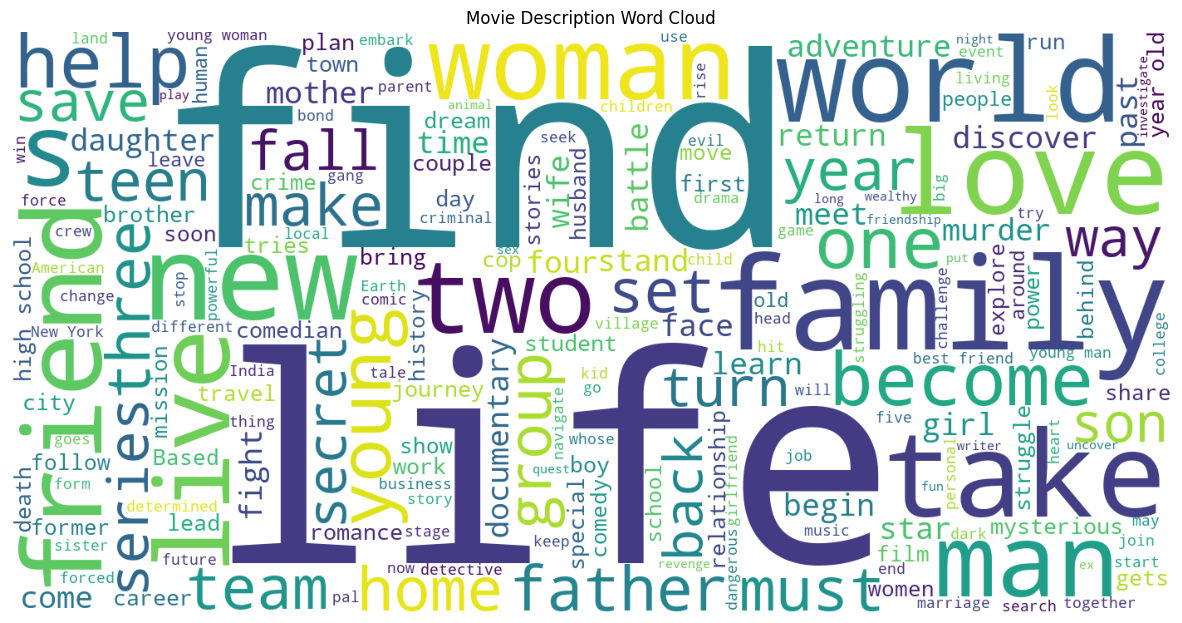

In [9]:
text = " ".join(df["description"].dropna())

wc = WordCloud(
    width=1400,
    height=700,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wc)

plt.axis("off")

plt.title("Movie Description Word Cloud")

plt.savefig("../images/12_description_wordcloud.png")

plt.show()

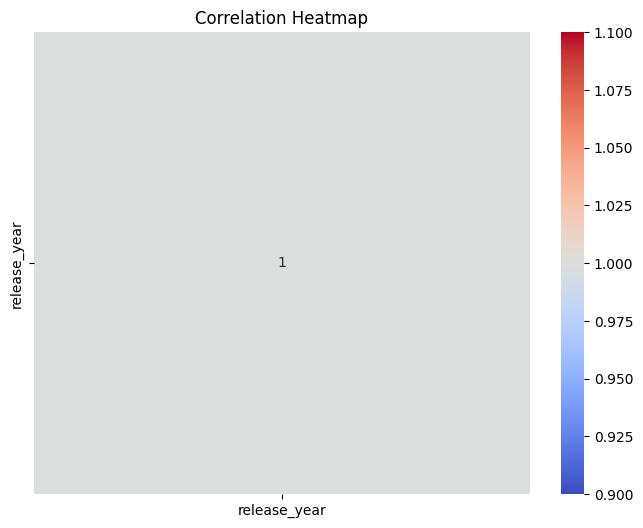

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../images/13_heatmap.png")

plt.show()

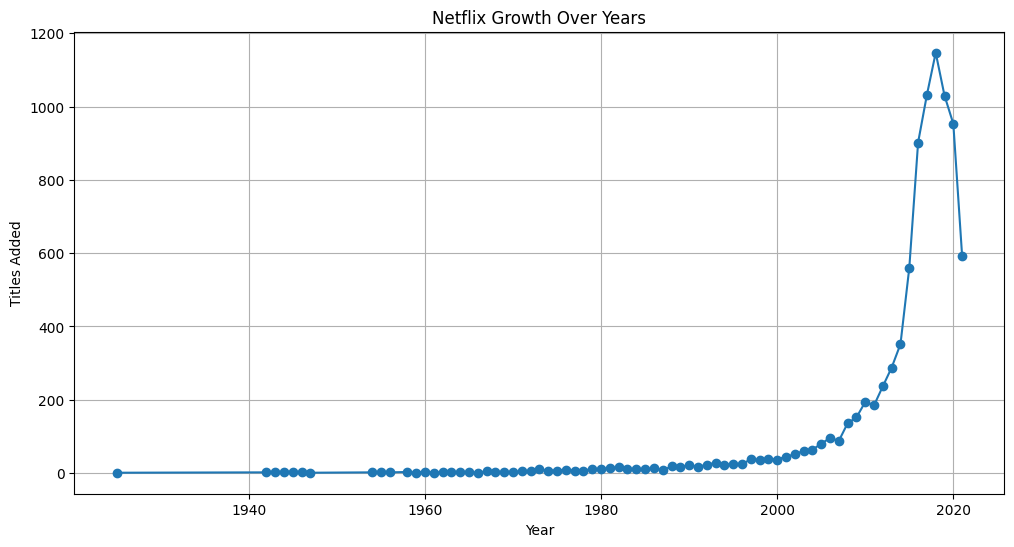

In [14]:
yearly = (
    df.groupby("release_year")
    .size()
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o"
)

plt.title("Netflix Growth Over Years")

plt.xlabel("Year")

plt.ylabel("Titles Added")

plt.grid(True)

plt.savefig("../images/14_growth_trend.png")

plt.show()

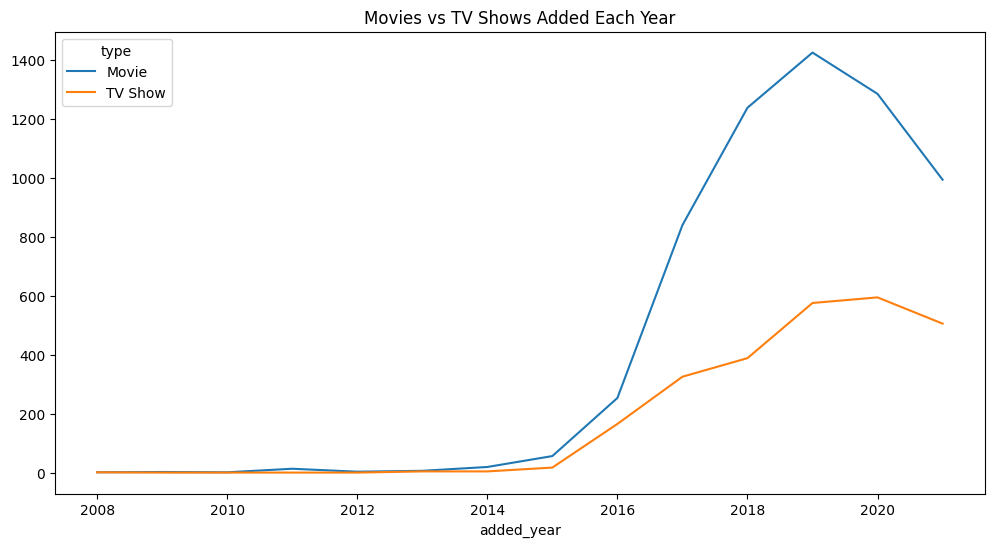

In [ ]:
df["added_year"] = pd.to_datetime(df["date_added"], errors="coerce").dt.year

pivot = pd.pivot_table(
    df,
    index="added_year",
    columns="type",
    aggfunc="size",
    fill_value=0
)

pivot.plot(figsize=(12,6))

plt.title("Movies vs TV Shows Added Each Year")

plt.savefig("../images/15_movies_tv_year.png")

plt.show()